In [1]:
%matplotlib inline
from __future__ import division
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
from numba import jit
import os
import re
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
#from torchvision import datasets, transforms

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


In [3]:
def sort_beta(file):
    #print(file)
    beta = re.search('beta_(.+?)_', file).group(1)
    return float(beta)

In [4]:
N=30
type_folder = 'Hex_ferro_v2' 
inputfolder ='./'+type_folder+'/data_N_'+str(N)+'_train'
myfiles = os.listdir(inputfolder)
#myfiles.remove('.DS_Store')
myfiles.sort(key = sort_beta)

(16000, 60, 60)
(16000,)
2.0


/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_31052/140713515.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X= torch.tensor(X, dtype=torch.float)
/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_31052/140713515.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y= torch.tensor(y, dtype=torch.long)


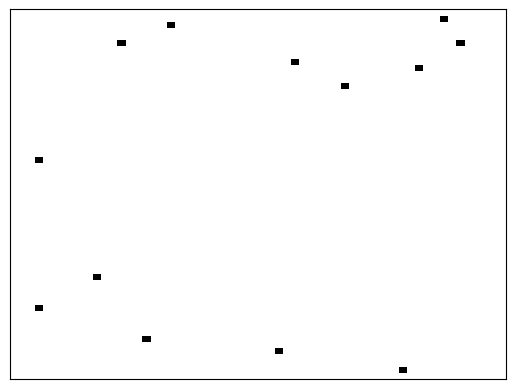

In [5]:
#print(myfiles)
#test = np.loadtxt(inputfolder+'/'+str(myfiles[0]))
#N = test.shape[0] #number of spins

betas= []
labels = []
data=[]

for i in range(len(myfiles)):
    #print(myfiles[i])
    
    #if (i % 2) == 0:
    beta = re.search('beta_(.+?)_', myfiles[i]).group(1)
    betas.append(float(beta))
    #data[i,:] = np.loadtxt('./data/'+str(myfiles[i]))
    data.append(np.loadtxt(inputfolder+'/'+str(myfiles[i])))
    if 1/float(beta) > 3.641:
        labels.append(0) #paramagnet above Tc
    else: labels.append(1) #ferromagnet below Tc

data=np.asarray(data)

#Duplicate data to expand training data set
numCopies =4
data = np.repeat(data, numCopies, axis=0)
print(data.shape)

#flip half of the spins at each temperature to double configurations in data
for i in range(int(len(data)/int(numCopies/2))):
    if (i % 2) == 0:
        #print(i*int(numCopies/2),(i+1)*int(numCopies/2))
        data[i*int(numCopies/2):(i+1)*int(numCopies/2)]*=-1



X = torch.from_numpy(data)
X= torch.tensor(X, dtype=torch.float)

y = np.asarray(labels)
y=np.repeat(y,numCopies)
print(y.shape)
y = torch.from_numpy(y)
y= torch.tensor(y, dtype=torch.long)

betas=np.asarray(betas)
betas = np.repeat(betas, numCopies)
#print(y)

Xfig, Yfig = np.meshgrid(range(N), range(N))
plt.figure() 
#plt.setp(sp.get_yticklabels(), visible=False)
#plt.setp(sp.get_xticklabels(), visible=False)      
plt.pcolormesh(Xfig, Yfig, data[-1], cmap=plt.cm.binary);
# getting current axes
a = plt.gca()

# set visibility of x-axis as False
xax = a.axes.get_xaxis()
xax = xax.set_visible(False)

# set visibility of y-axis as False
yax = a.axes.get_yaxis()
yax = yax.set_visible(False)
plt.axis('tight') 
print(1/betas[-1])

In [6]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

print(X_train.shape)
print(y_train.shape)

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
y_train = y_train.type(torch.LongTensor)
y_test = y_test.type(torch.LongTensor)

print(X_train.shape)
print(y_train.shape)


torch.Size([10720, 60, 60])
torch.Size([10720])
torch.Size([10720, 3600])
torch.Size([10720])


In [7]:
class MnistDataset(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [8]:
class Trainer:
    
    def __init__(self, model, opt_method, learning_rate, batch_size, epoch, l2):
        self.model = model
        # calulate the number of parameters
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        if opt_method == "adam":
            self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        elif opt_method == "sgdm":
            # Hint: to use SGDM in PyTorch, use torch.optim.SGD and set momentum to a non-zero value
            self.optimizer = torch.optim.SGD(model.parameters(), learning_rate, momentum = 0)
        else:
            raise NotImplementedError("This optimization is not supported")
        
        self.epoch = epoch
        self.batch_size = batch_size
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        train_loader = DataLoader(train_data, batch_size=self.batch_size, shuffle=True)
        
        train_loss_list, train_acc_list = [], []
        val_loss_list, val_acc_list = [], []
        weights = self.model.state_dict()
        lowest_val_loss = np.inf
        loss_func = nn.CrossEntropyLoss()
        
        for n in tqdm(range(self.epoch), leave=False):
            # enable train mode
            self.model.train()
            epoch_loss, epoch_acc = 0.0, 0.0
            for X_batch, y_batch in train_loader:
                batch_importance = y_batch.shape[0]/len(train_data)
                y_pred = self.model(X_batch)
                batch_loss = loss_func(y_pred, y_batch)
                
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                epoch_loss += batch_loss.detach().cpu().item() * batch_importance
                batch_acc = torch.sum(torch.argmax(y_pred, axis=1) == y_batch) / y_batch.shape[0]
                epoch_acc += batch_acc.detach().cpu().item() * batch_importance
            
            train_loss_list.append(epoch_loss)
            train_acc_list.append(epoch_acc)
            val_loss, val_acc = self.evaluate(val_data)
            val_loss_list.append(val_loss)
            val_acc_list.append(val_acc)
            
            if early_stop:
                if val_loss < lowest_val_loss:
                    lowest_val_loss = val_loss
                    weights = self.model.state_dict()
            
        if draw_curve:
            x_axis = np.arange(self.epoch)
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].plot(x_axis, train_loss_list, label="Train")
            axes[0].plot(x_axis, val_loss_list, label="Validation")
            axes[0].set_title("Loss")
            axes[0].legend()
            axes[1].plot(x_axis, train_acc_list, label='Train')
            axes[1].plot(x_axis, val_acc_list, label='Validation')
            axes[1].set_title("Accuracy")
            axes[1].legend()
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return {
            "train_loss_list": train_loss_list,
            "train_acc_list": train_acc_list,
            "val_loss_list": val_loss_list,
            "val_acc_list": val_acc_list,
        }
    
    def evaluate(self, data, print_acc=False):
        # enable evaluation mode
        self.model.eval()
        loader = DataLoader(data, batch_size=self.batch_size, shuffle=True)
        loss_func = nn.CrossEntropyLoss()
        acc, loss = 0.0, 0.0
        for X_batch, y_batch in loader:
            with torch.no_grad():
                batch_importance = y_batch.shape[0]/ len(data)
                y_pred = self.model(X_batch)
                batch_loss = loss_func(y_pred, y_batch)
                batch_acc = torch.sum(torch.argmax(y_pred, axis=1) == y_batch) / y_batch.shape[0]
                acc += batch_acc.detach().cpu().item() * batch_importance
                loss += batch_loss.detach().cpu().item() * batch_importance
        if print_acc:
            print(f"Accuracy: {acc:.3f}")
        return loss, acc

In [9]:
def KFoldCrossValidation(PATH, model_class, k, 
    X_train, y_train, X_test, y_test, 
    opt_method='adam', 
    learning_rate=1e-4, batch_size=100, epoch=200, l2=0.0 ):
    
    # Use MnistDataset to organize data
    test_data = MnistDataset(X_test, y_test)
    kf = KFold(n_splits=k, shuffle= True )
    train_acc_list, test_acc_list = [], []
    
    for i, (train_index, val_index) in enumerate(kf.split(X_train)):
        
        print(f"Fold {i}:")
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
        #X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1) # 0.25 x 0.8 = 0.2
        
        # Use MnistDataset to organize data
        train_data = MnistDataset(X_train_fold, y_train_fold)
        val_data = MnistDataset(X_val_fold, y_val_fold)
        
        model = model_class()
        
        # initialize a Trainer object
        trainer = Trainer(model, 'adam', learning_rate=1e-4, 
                          batch_size=100, epoch=200, l2=0.0)
        
        # call trainer.train() here
        res = trainer.train(train_data, val_data)
        # record the training accuracy of the epoch that has the lowest valiation lost
        # Hint: use np.argmin
        train_acc_best = res['train_acc_list'][np.argmin(res['val_loss_list'])]
        # test, use trainer.evaluate function
        test_loss, test_acc = trainer.evaluate(test_data)
        
        train_acc_list.append(train_acc_best)
        test_acc_list.append(test_acc)
        
        print(f"Training accuracy: {train_acc_best}")
        print(f"Test accuracy: {test_acc}")
    
    
    torch.save(model.state_dict(), PATH)

    print("Final results:")
    # Report mean and std
    print(f"Training accuracy:", np.mean(train_acc_list), np.std(train_acc_list))
    print(f"Test accuracy:", np.mean(test_acc_list), np.std(test_acc_list))
    

In [10]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(nn.Linear(N**2,50 ),
                                    nn.ReLU(),
                                    nn.Linear(50,2),
                                    nn.Softmax()
                                    )
    def forward(self, x):
        return self.layers(x)

Fold 0:
Net - Number of parameters: 180152


  0%|                                                                                                                                                               | 0/200 [00:00<?, ?it/s]/Users/GBordia/anaconda3/envs/c142/lib/python3.8/site-packages/torch/nn/modules/module.py:1511: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Training accuracy: 0.9999999999999999
Test accuracy: 0.9685606114340541
Fold 1:
Net - Number of parameters: 180152


Training accuracy: 0.9999999999999999
Test accuracy: 0.9715909192507911
Final results:
Training accuracy: 0.9999999999999999 0.0
Test accuracy: 0.9700757653424226 0.0015151539083684828


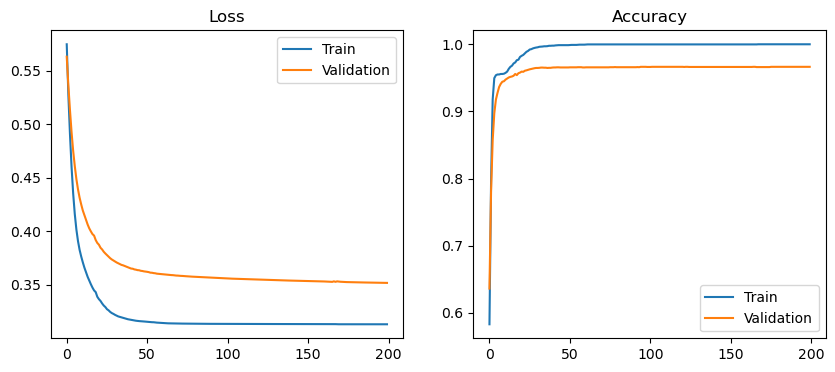

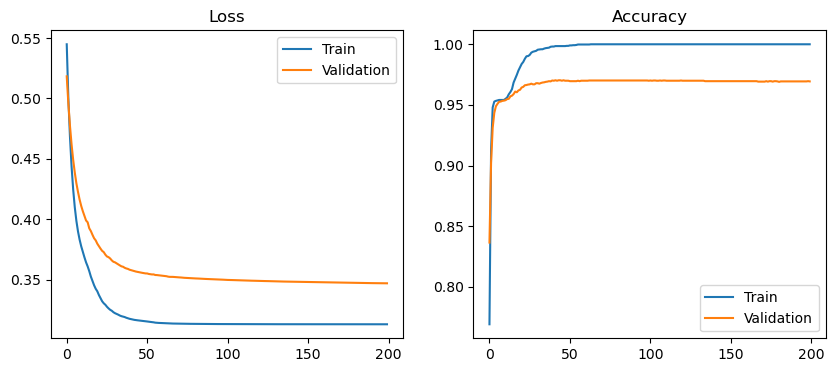

In [11]:
PATH = './'+type_folder+'_FeedForwardNetworks/net_N_'+str(N)+'_.pth'
KFoldCrossValidation( PATH, Net, 2, X_train, y_train, X_test, y_test)

In [12]:
net = Net()
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [13]:
betas= []
labels = []
data = np.zeros((  int(len(myfiles)) ,N,N))
for i in range(len(myfiles)):
    #print(myfiles[i])
    
    beta = re.search('beta_(.+?)_', myfiles[i]).group(1)
    betas.append(float(beta))
    data[i,:] = np.loadtxt(inputfolder+'/'+str(myfiles[i]))
    if 1/float(beta) > 3.641:
        labels.append(0) #paramagnet above Tc
    else: labels.append(1) #ferromagnet below Tc



(16000, 60, 60)
(16000,)
(16000,)
[[9.9998558e-01 1.4417757e-05]
 [9.9998558e-01 1.4417757e-05]
 [9.9998558e-01 1.4417757e-05]
 ...
 [5.5568989e-06 9.9999440e-01]
 [5.5568989e-06 9.9999440e-01]
 [5.5568989e-06 9.9999440e-01]]
torch.Size([16000, 3600])
(16000, 2)
tensor([0, 0, 0,  ..., 1, 1, 1])
[0.18181818 0.18181818 0.18181818 ... 0.5        0.5        0.5       ]
4


/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_31052/1917732746.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X= torch.tensor(X, dtype=torch.float)
/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_31052/1917732746.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y= torch.tensor(y, dtype=torch.long)


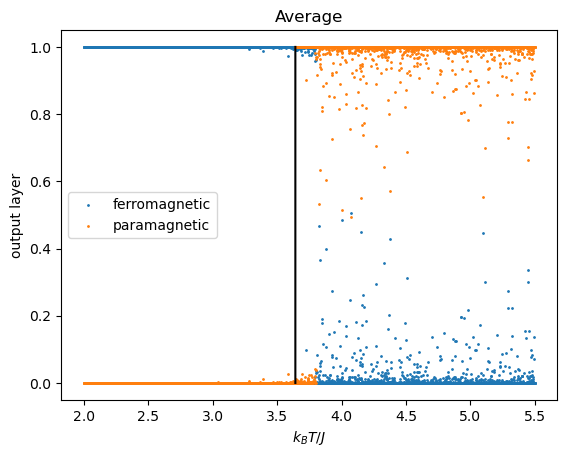

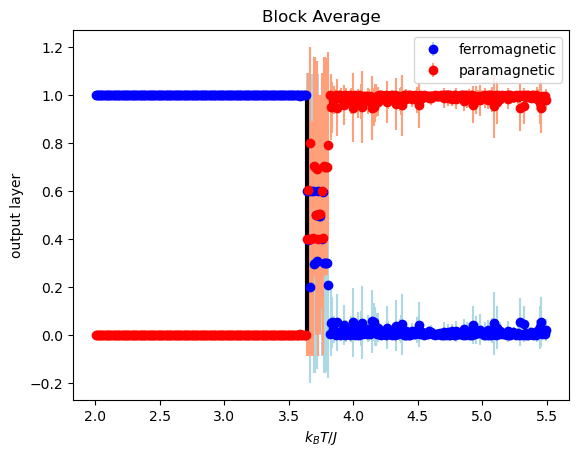

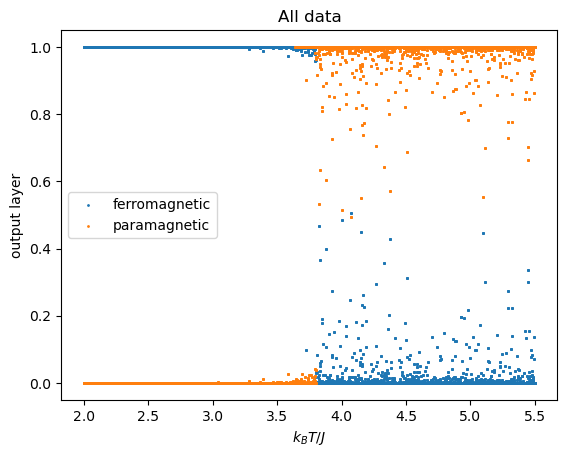

In [14]:
data = np.repeat(data, numCopies, axis=0)
print(data.shape)

X = torch.from_numpy(data)
X= torch.tensor(X, dtype=torch.float)

X = X.reshape(X.shape[0], -1)

y = np.asarray(labels)
y=np.repeat(y,numCopies)
print(y.shape)
y = torch.from_numpy(y)
y= torch.tensor(y, dtype=torch.long)

betas=np.asarray(betas)
betas = np.repeat(betas, numCopies)
print(betas.shape)

outputs = net(X)
outputs = outputs.detach().numpy()
print(outputs)
print(X.shape)
print(outputs.shape)
print(y)
print(betas)

print(numCopies)


numT = int(len(betas)/numCopies)

beta_vals=np.zeros(numT)
ferro= np.zeros(numT)
para=np.zeros(numT)

ferro_std= np.zeros(numT)
para_std=np.zeros(numT)


for i in range(numT):
    beta_vals[i] = np.mean(betas[i*numCopies:(i+1)*numCopies])
    #print(np.mean(outputs[i*numCopies:(i+1)*numCopies, 0]))
    #print(np.std(outputs[i*numCopies:(i+1)*numCopies, 0]))
    
    ferro[i] = np.mean(outputs[i*numCopies:(i+1)*numCopies, 1])
    ferro_std[i] = np.std(outputs[i*numCopies:(i+1)*numCopies, 1])

    #print(ferro[i])
    #print(outputs[i*numCopies:(i+1)*numCopies, 0])
    #print(ferro[i])
    para[i]  = np.mean(outputs[i*numCopies:(i+1)*numCopies, 0])
    para_std[i] = np.std(outputs[i*numCopies:(i+1)*numCopies, 0])

    #print(outputs[i*numCopies:(i+1)*numCopies, 1])
    #print(para[i])

# print(para_std)
# print(ferro_std)
# print(np.where(para_std >10**-7))
# print(np.where(ferro_std >10**-7))


##### Block averaging the data

bsize= 10
bAvgFerro = np.zeros(int(len(ferro)/bsize))
bAvgPara = np.zeros(int(len(para)/bsize))
bAvgBeta = np.zeros(int(len(beta_vals)/bsize))
bStdFerro = np.zeros(int(len(ferro)/bsize))
bStdPara = np.zeros(int(len(para)/bsize))
bStdBeta = np.zeros(int(len(beta_vals)/bsize))

for i in range(int(len(ferro)/bsize)):
    #bAvgFerro[i] = np.sum( ferro[i*bsize:(i+1)*bsize])/bsize
    bAvgFerro[i] = np.mean( ferro[i*bsize:(i+1)*bsize])
    bStdFerro[i] = np.std( ferro[i*bsize:(i+1)*bsize])
    #bAvgPara[i]  = np.sum( para[i*bsize:(i+1)*bsize])/bsize
    bAvgPara[i]  = np.mean( para[i*bsize:(i+1)*bsize])
    bStdPara[i]  = np.std( para[i*bsize:(i+1)*bsize])
    #bAvgBeta[i]  = np.sum( beta_vals[i*bsize:(i+1)*bsize])/bsize
    bAvgBeta[i]  = np.mean( beta_vals[i*bsize:(i+1)*bsize])
    bStdBeta[i]  = np.std( beta_vals[i*bsize:(i+1)*bsize])

#####


plt.figure()
plt.scatter(1/beta_vals, ferro, s=1, label='ferromagnetic')
plt.scatter(1/beta_vals, para, s=1, label='paramagnetic')
plt.plot(np.ones(len(beta_vals))*3.641, np.linspace(0,1, len(beta_vals)), color='black')
plt.xlabel(r'$k_{B}T/J$')
plt.ylabel('output layer')
plt.title('Average')
plt.legend()

plt.figure()
#plt.plot(1/bAvgBeta, bAvgFerro, label='ferromagnetic')
#plt.plot(1/bAvgBeta, bAvgPara, label='paramagnetic')
plt.errorbar(1/bAvgBeta, bAvgFerro, yerr=bStdFerro, fmt="o", 
             color='blue', ecolor='lightblue', elinewidth=None, 
             capsize=0, label='ferromagnetic')

plt.errorbar(1/bAvgBeta, bAvgPara, yerr=bStdPara, fmt="o", 
             color='red', ecolor='lightsalmon', elinewidth=None, 
             capsize=0, label='paramagnetic')

plt.plot(np.ones(len(bAvgBeta))*3.641, np.linspace(0,1, len(bAvgBeta)), linewidth =3, color='black')
plt.xlabel(r'$k_{B}T/J$')
plt.ylabel('output layer')
plt.title('Block Average')
plt.legend()

plt.figure()
plt.scatter(1/betas, outputs[:,1], s=1, label='ferromagnetic')
plt.scatter(1/betas, outputs[:,0], s=1, label='paramagnetic')
plt.xlabel(r'$k_{B}T/J$')
plt.ylabel('output layer')
plt.title('All data')
plt.legend()

# plt.figure()
# plt.scatter(np.arange(len(para_std)), para_std)
# plt.scatter(np.arange(len(para_std)), ferro_std)


In [15]:
# class Net50Dropout(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.layers = nn.Sequential(
#             nn.Linear(N**2, 50),
#             nn.Dropout(p=0.15),
#             nn.Sigmoid(),
#             nn.Linear(50, 2),
#             nn.Dropout(p=0.15),
#             nn.Sigmoid()
#         )
    
#     def forward(self, x):
#         return self.layers(x)

In [16]:
# PATH = './net50Dropout.pth'
# KFoldCrossValidation(PATH, Net50Dropout, 3, X_train, y_train, X_test, y_test)

In [17]:
# net = Net50Dropout()
# net.load_state_dict(torch.load(PATH))

In [18]:
# X = torch.from_numpy(data)
# X= torch.tensor(X, dtype=torch.float)

# X = X.reshape(X.shape[0], -1)


# outputs = net(X)
# outputs = outputs.detach().numpy()
# print(outputs)
# print(X.shape)
# print(outputs.shape)
# print(y)
# print(betas)

# print(numCopies)


# numT = int(len(betas)/numCopies)

# beta_vals=np.zeros(numT)
# ferro= np.zeros(numT)
# para=np.zeros(numT)

# ferro_std= np.zeros(numT)
# para_std=np.zeros(numT)


# for i in range(numT):
#     beta_vals[i] = np.mean(betas[i*numCopies:(i+1)*numCopies])
#     #print(np.mean(outputs[i*numCopies:(i+1)*numCopies, 0]))
#     #print(np.std(outputs[i*numCopies:(i+1)*numCopies, 0]))
    
#     ferro[i] = np.mean(outputs[i*numCopies:(i+1)*numCopies, 1])
#     ferro_std[i] = np.std(outputs[i*numCopies:(i+1)*numCopies, 1])

#     #print(ferro[i])
#     #print(outputs[i*numCopies:(i+1)*numCopies, 0])
#     #print(ferro[i])
#     para[i]  = np.mean(outputs[i*numCopies:(i+1)*numCopies, 0])
#     para_std[i] = np.std(outputs[i*numCopies:(i+1)*numCopies, 0])

#     #print(outputs[i*numCopies:(i+1)*numCopies, 1])
#     #print(para[i])

# # print(para_std)
# # print(ferro_std)
# # print(np.where(para_std >10**-7))
# # print(np.where(ferro_std >10**-7))


# plt.figure()
# plt.scatter(1/beta_vals, ferro, s=1, label='ferromagnetic')
# plt.scatter(1/beta_vals, para, s=1, label='paramagnetic')
# plt.xlabel(r'$k_{B}T/J$')
# plt.ylabel('output layer')
# plt.title('Average')
# plt.legend()

# plt.figure()
# plt.scatter(1/betas, outputs[:,1], s=1, label='ferromagnetic')
# plt.scatter(1/betas, outputs[:,0], s=1, label='paramagnetic')
# plt.xlabel(r'$k_{B}T/J$')
# plt.ylabel('output layer')
# plt.title('All data')
# plt.legend()

# plt.figure()
# plt.scatter(np.arange(len(para_std)), para_std)
# plt.scatter(np.arange(len(para_std)), ferro_std)